#### Import necessary libraries to data wrangling, manupulation and visualisation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Fraud Transaction Detection Using Transactions Dataset

" Step 1: Extract the .zip file in memory
Since the data is inside a .zip file and stored in .pkl format, we can use the zipfile and pickle modules to read the data. "

In [3]:
import zipfile
import pickle

# Path to the .zip file
zip_path = r"d:\Projects\fraud_detection\dataset.zip"

# Open the ZIP file
with zipfile.ZipFile(zip_path, 'r') as z:  # Open the ZIP File
    data_dict = {}  # Initialize a Dictionary to Store Loaded Data

    # Loop through all .pkl files in the zip
    for pkl_file in [f for f in z.namelist() if f.endswith('.pkl')]:  # Find All .pkl Files in the ZIP
        with z.open(pkl_file) as f:
            try:
                data = pd.read_pickle(f)  # Try loading with Pandas
            except Exception:
                f.seek(0)  # Reset file pointer
                data = pickle.load(f)  # Try standard pickle

            data_dict[pkl_file] = data  # Store data
            print(f"Loaded {pkl_file}: {type(data)}")  # Print file type

# Summary of loaded files
print("\nSummary of Loaded Data:")
for file, content in data_dict.items():
    print(f"{file}: {type(content)}")

Loaded data/2018-04-01.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-02.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-03.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-04.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-05.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-06.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-07.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-08.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-09.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-10.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-11.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-12.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-13.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-14.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded data/2018-04-15.pkl: <class 'pandas.core.frame.DataFrame'>
Loaded dat

In [4]:
data_dict.values()

dict_values([      TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  TX_AMOUNT  \
0                  0 2018-04-01 00:00:31         596        3156      57.16   
1                  1 2018-04-01 00:02:10        4961        3412      81.51   
2                  2 2018-04-01 00:07:56           2        1365     146.00   
3                  3 2018-04-01 00:09:29        4128        8737      64.49   
4                  4 2018-04-01 00:10:34         927        9906      50.99   
...              ...                 ...         ...         ...        ...   
9483            9483 2018-04-01 23:56:50        3289        6699      48.69   
9484            9484 2018-04-01 23:58:14        3230        6664      85.97   
9485            9485 2018-04-01 23:58:31         296        3702     120.88   
9486            9486 2018-04-01 23:59:28        2557         146       8.02   
9487            9487 2018-04-01 23:59:51         554        8248      19.20   

     TX_TIME_SECONDS TX_TIME_DAYS  TX_

In [5]:
data_dict.keys()

dict_keys(['data/2018-04-01.pkl', 'data/2018-04-02.pkl', 'data/2018-04-03.pkl', 'data/2018-04-04.pkl', 'data/2018-04-05.pkl', 'data/2018-04-06.pkl', 'data/2018-04-07.pkl', 'data/2018-04-08.pkl', 'data/2018-04-09.pkl', 'data/2018-04-10.pkl', 'data/2018-04-11.pkl', 'data/2018-04-12.pkl', 'data/2018-04-13.pkl', 'data/2018-04-14.pkl', 'data/2018-04-15.pkl', 'data/2018-04-16.pkl', 'data/2018-04-17.pkl', 'data/2018-04-18.pkl', 'data/2018-04-19.pkl', 'data/2018-04-20.pkl', 'data/2018-04-21.pkl', 'data/2018-04-22.pkl', 'data/2018-04-23.pkl', 'data/2018-04-24.pkl', 'data/2018-04-25.pkl', 'data/2018-04-26.pkl', 'data/2018-04-27.pkl', 'data/2018-04-28.pkl', 'data/2018-04-29.pkl', 'data/2018-04-30.pkl', 'data/2018-05-01.pkl', 'data/2018-05-02.pkl', 'data/2018-05-03.pkl', 'data/2018-05-04.pkl', 'data/2018-05-05.pkl', 'data/2018-05-06.pkl', 'data/2018-05-07.pkl', 'data/2018-05-08.pkl', 'data/2018-05-09.pkl', 'data/2018-05-10.pkl', 'data/2018-05-11.pkl', 'data/2018-05-12.pkl', 'data/2018-05-13.pkl', 

In [6]:
data_dict['data/2018-04-02.pkl'].T

,9488,9489,9490,9491,9492,9493,9494,9495,9496,9497,...,19061,19062,19063,19064,19065,19066,19067,19068,19069,19070
TRANSACTION_ID,9488,9489,9490,9491,9492,9493,9494,9495,9496,9497,...,19061,19062,19063,19064,19065,19066,19067,19068,19069,19070
TX_DATETIME,2018-04-02 00:00:11,2018-04-02 00:01:08,2018-04-02 00:01:16,2018-04-02 00:01:27,2018-04-02 00:01:48,2018-04-02 00:02:05,2018-04-02 00:02:23,2018-04-02 00:02:23,2018-04-02 00:03:32,2018-04-02 00:03:41,...,2018-04-02 23:51:22,2018-04-02 23:52:03,2018-04-02 23:52:14,2018-04-02 23:53:52,2018-04-02 23:53:53,2018-04-02 23:57:04,2018-04-02 23:57:22,2018-04-02 23:57:32,2018-04-02 23:58:16,2018-04-02 23:58:31
CUSTOMER_ID,2221,3535,4974,4259,2896,2604,826,2587,2921,697,...,259,4376,3339,4985,1197,4092,1561,2420,4720,2958
TERMINAL_ID,6047,2848,313,5014,4117,7807,121,4114,9807,1280,...,7119,3712,2906,8500,4771,8590,7871,953,7759,1519
TX_AMOUNT,21.24,60.47,75.04,27.93,82.06,72.26,99.67,133.52,63.6,70.01,...,16.22,28.89,12.44,20.67,107.07,39.53,73.36,48.94,54.2,45.86
TX_TIME_SECONDS,86411,86468,86476,86487,86508,86525,86543,86543,86612,86621,...,172282,172323,172334,172432,172433,172624,172642,172652,172696,172711
TX_TIME_DAYS,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
TX_FRAUD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TX_FRAUD_SCENARIO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Description of Main Columns:

- **TRANSACTION_ID**: A unique identifier for the transaction.
- **TX_DATETIME**: Date and time at which the transaction occurs.
- **CUSTOMER_ID**: The identifier for the customer. Each customer has a unique identifier.
- **TERMINAL_ID**: The identifier for the merchant (or more precisely the terminal). Each terminal has a unique identifier.
- **TX_AMOUNT**: The amount of the transaction.
- **TX_FRAUD**: A binary variable, with the value 0 for a legitimate transaction, 1 for a fraudulent transaction.


In [7]:
# Combine all DataFrames into one
df_list = [df for df in data_dict.values() if isinstance(df, pd.DataFrame)]  # Select only DataFrames
if df_list:
    comb_df = pd.concat(df_list, ignore_index=True)  # Merge all DataFrames
    print("\n✅ Combined DataFrame:")
else:
    print("\n⚠️ No DataFrames found to combine.")


✅ Combined DataFrame:


In [8]:
comb_df.head().T

,0,1,2,3,4
TRANSACTION_ID,0,1,2,3,4
TX_DATETIME,2018-04-01 00:00:31,2018-04-01 00:02:10,2018-04-01 00:07:56,2018-04-01 00:09:29,2018-04-01 00:10:34
CUSTOMER_ID,596,4961,2,4128,927
TERMINAL_ID,3156,3412,1365,8737,9906
TX_AMOUNT,57.16,81.51,146.0,64.49,50.99
TX_TIME_SECONDS,31,130,476,569,634
TX_TIME_DAYS,0,0,0,0,0
TX_FRAUD,0,0,0,0,0
TX_FRAUD_SCENARIO,0,0,0,0,0


In [9]:
comb_df.describe().T

,count,mean,min,25%,50%,75%,max,std
TRANSACTION_ID,1754155.0,877077.0,0.0,438538.5,877077.0,1315615.5,1754154.0,506381.075063
TX_DATETIME,1754155,2018-07-01 11:20:33.708572160,2018-04-01 00:00:31,2018-05-16 14:40:46.500000,2018-07-01 11:11:10,2018-08-16 08:01:01.500000,2018-09-30 23:59:57,NaN
TX_AMOUNT,1754155.0,53.632302,0.0,21.01,44.64,76.95,2628.0,42.326492
TX_FRAUD,1754155.0,0.008369,0.0,0.0,0.0,0.0,1.0,0.0911
TX_FRAUD_SCENARIO,1754155.0,0.018824,0.0,0.0,0.0,0.0,3.0,0.211326


In [10]:
comb_df.shape

(1754155, 9)

In [11]:
# prompt: check each columns value counts of the given data set

for column in comb_df.columns:
  print(f"Value counts for column '{column}':")
  print(comb_df[column].value_counts())
  print("\n")


Value counts for column 'TRANSACTION_ID':
TRANSACTION_ID
1754154    1
0          1
1          1
2          1
3          1
          ..
15         1
14         1
13         1
12         1
11         1
Name: count, Length: 1754155, dtype: int64


Value counts for column 'TX_DATETIME':
TX_DATETIME
2018-07-02 12:10:19    6
2018-07-30 14:08:48    6
2018-05-07 11:43:53    5
2018-05-17 08:38:32    5
2018-04-07 09:45:29    5
                      ..
2018-04-01 00:20:03    1
2018-04-01 00:20:25    1
2018-04-01 00:20:40    1
2018-04-01 00:20:48    1
2018-09-30 23:59:57    1
Name: count, Length: 1635076, dtype: int64


Value counts for column 'CUSTOMER_ID':
CUSTOMER_ID
382     767
3864    762
2891    761
775     754
1411    752
       ... 
4534      1
3801      1
822       1
3253      1
1942      1
Name: count, Length: 4990, dtype: int64


Value counts for column 'TERMINAL_ID':
TERMINAL_ID
4018    376
692     372
5295    368
8130    360
872     356
       ... 
9180     57
4477     56
3789     54


In [12]:
comb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


In [13]:
# Convert CUSTOMER_ID and TERMINAL_ID to categorical
comb_df['CUSTOMER_ID'] = comb_df['CUSTOMER_ID'].astype('category')
comb_df['TERMINAL_ID'] = comb_df['TERMINAL_ID'].astype('category')

# Convert TX_TIME_SECONDS and TX_TIME_DAYS to numeric
comb_df['TX_TIME_SECONDS'] = pd.to_numeric(comb_df['TX_TIME_SECONDS'], errors='coerce')
comb_df['TX_TIME_DAYS'] = pd.to_numeric(comb_df['TX_TIME_DAYS'], errors='coerce')

# Verify the changes
comb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        category      
 3   TERMINAL_ID        category      
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    int64         
 6   TX_TIME_DAYS       int64         
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(5)
memory usage: 100.9 MB


# Handle Missing Values
Identify missing values in the dataset and apply strategies to handle them, such as imputation or removal.

In [14]:
# Identify missing values in the dataset
missing_values = comb_df.isnull().sum()  # Count missing values in each column
missing_percentage = (missing_values / len(comb_df)) * 100  # Calculate percentage of missing values
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("Summary of missing values:")
display(missing_summary)

# Handle missing values
# Example strategy: Drop columns with more than 50% missing values
threshold = 50
columns_to_drop = missing_summary[missing_summary['Percentage'] > threshold].index
comb_df = comb_df.drop(columns=columns_to_drop)
print(f"\nDropped columns with more than {threshold}% missing values: {list(columns_to_drop)}")

# Example strategy: Impute missing values for numerical columns with the median
numerical_columns = comb_df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    if comb_df[col].isnull().sum() > 0:
        comb_df[col].fillna(comb_df[col].median(), inplace=True)
        print(f"Imputed missing values in numerical column '{col}' with median.")

# Example strategy: Impute missing values for categorical columns with the mode
categorical_columns = comb_df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if comb_df[col].isnull().sum() > 0:
        comb_df[col].fillna(comb_df[col].mode()[0], inplace=True)
        print(f"Imputed missing values in categorical column '{col}' with mode.")

# Verify that there are no missing values left
print("\nRemaining missing values after handling:")
display(comb_df.isnull().sum())

Summary of missing values:


,Missing Values,Percentage
TRANSACTION_ID,0,0.0
TX_DATETIME,0,0.0
CUSTOMER_ID,0,0.0
TERMINAL_ID,0,0.0
TX_AMOUNT,0,0.0
TX_TIME_SECONDS,0,0.0
TX_TIME_DAYS,0,0.0
TX_FRAUD,0,0.0
TX_FRAUD_SCENARIO,0,0.0



Dropped columns with more than 50% missing values: []

Remaining missing values after handling:


TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

# Feature Engineering


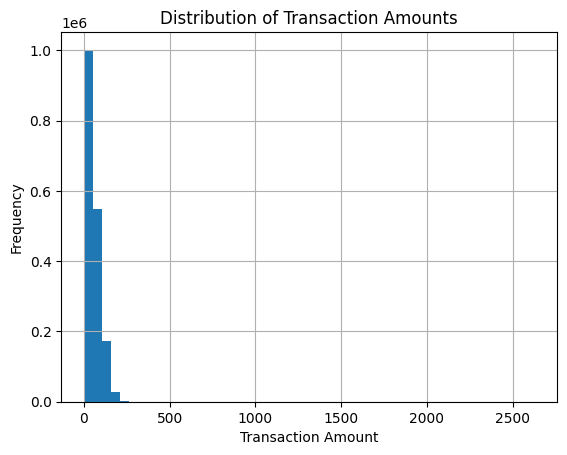

,count,mean,std,min,25%,50%,75%,max
TX_FRAUD,,,,,,,,
0,1739474.0,52.977907,39.421733,0.00,20.94,44.49,76.63,219.98
1,14681.0,131.168024,154.485795,0.02,32.98,72.22,177.30,2628.00


In [18]:
# Check the fraude senario with respect to transection amount : 

comb_df['TX_AMOUNT'].describe()  # Summary statistics for TX_AMOUNT
comb_df['TX_AMOUNT'].hist(bins=50)  # Histogram of TX_AMOUNT
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()  # Show the plot

# Check the distribution of transaction amounts by fraud status
comb_df['TX_AMOUNT'].groupby(comb_df['TX_FRAUD']).describe()  # Summary statistics by fraud status



In [14]:

# Create a new feature: Transaction Amount Log Transformation
comb_df['TransactionAmt_log'] = comb_df['TX_AMOUNT'].apply(lambda x: np.log1p(x) if x > 0 else 0)

# Encode categorical features using Label Encoding
from sklearn.preprocessing import LabelEncoder

categorical_features = comb_df.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for feature in categorical_features:
    le = LabelEncoder()
    comb_df[feature] = le.fit_transform(comb_df[feature].astype(str))
    label_encoders[feature] = le  # Save the encoder for future use

# Create a binary feature: High Transaction Amount (above 75th percentile)
high_transaction_threshold = comb_df['TX_AMOUNT'].quantile(0.75)
comb_df['High_TransactionAmt'] = (comb_df['TX_AMOUNT'] > high_transaction_threshold).astype(int)

# Display the first few rows of the dataset after feature engineering
print("Dataset after feature engineering:")
display(comb_df.head())

Dataset after feature engineering:


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TransactionAmt_log,High_TransactionAmt
0,0,2018-04-01 00:00:31,4542,2398,57.16,31,0,0,0,4.063198,0
1,1,2018-04-01 00:02:10,4394,2683,81.51,130,0,0,0,4.412919,1
2,2,2018-04-01 00:07:56,1110,408,146.00,476,0,0,0,4.990433,1
3,3,2018-04-01 00:09:29,3469,8598,64.49,569,0,0,0,4.181897,0
4,4,2018-04-01 00:10:34,4910,9897,50.99,634,0,0,0,3.951051,0


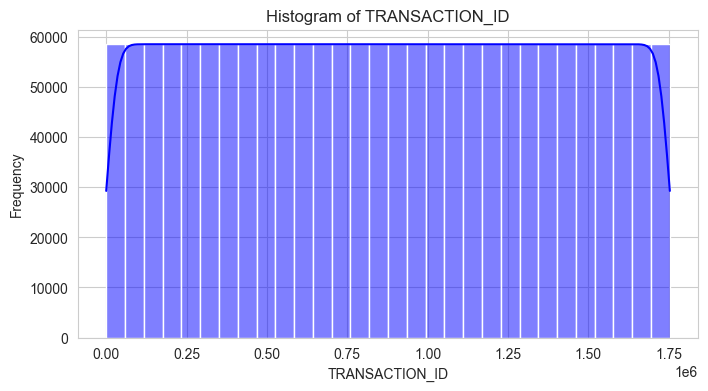

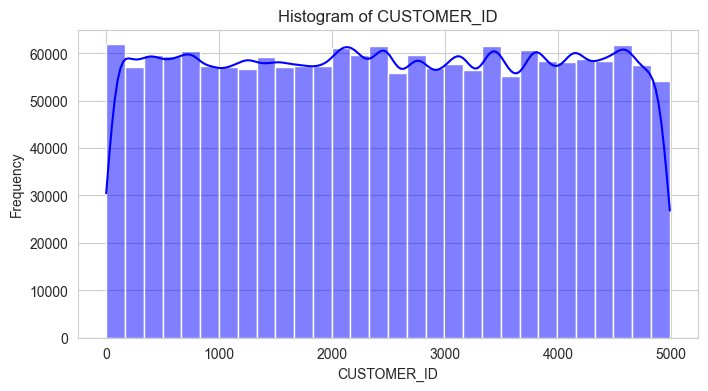

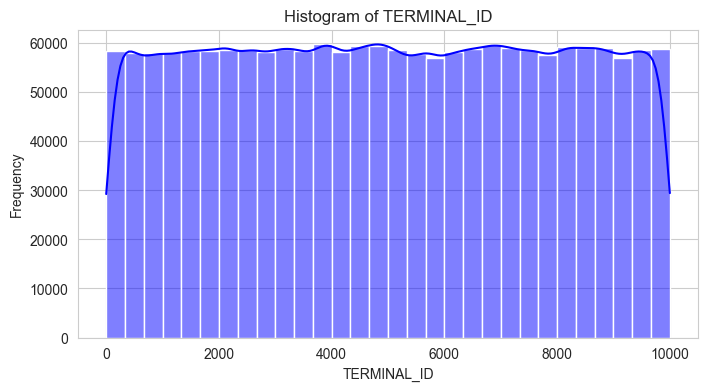

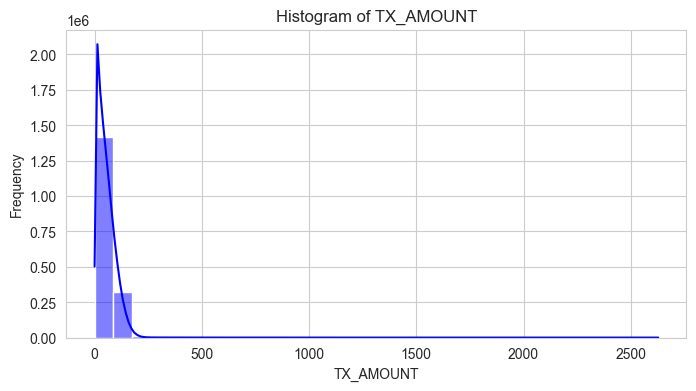

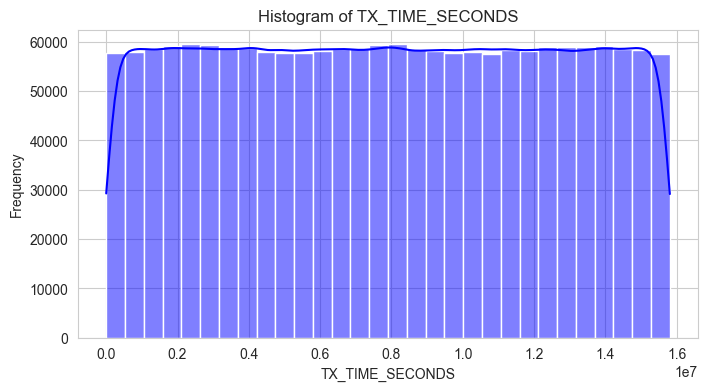

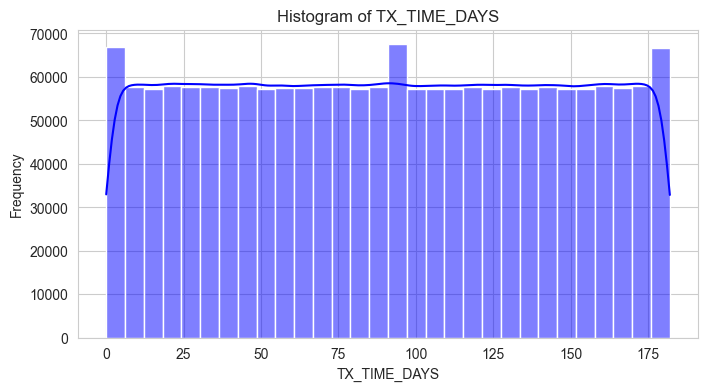

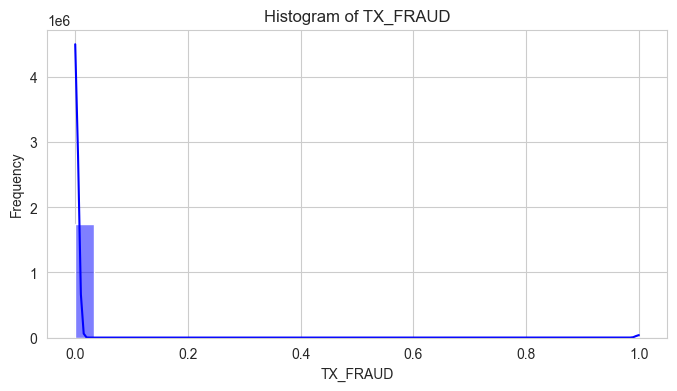

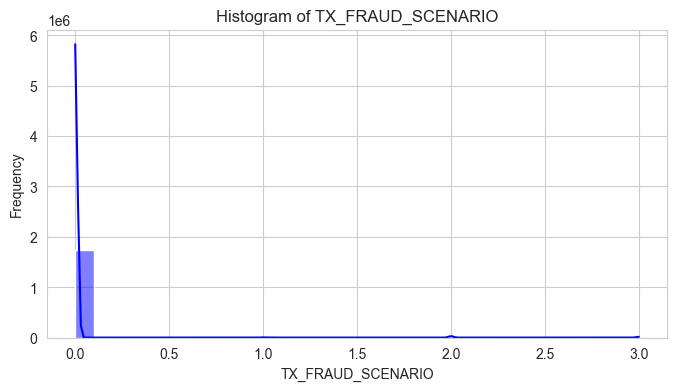

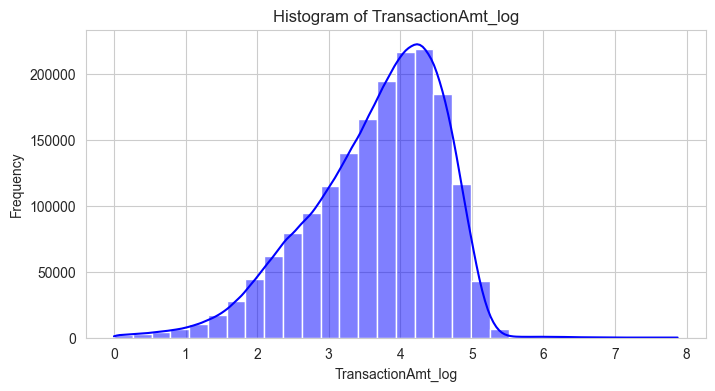

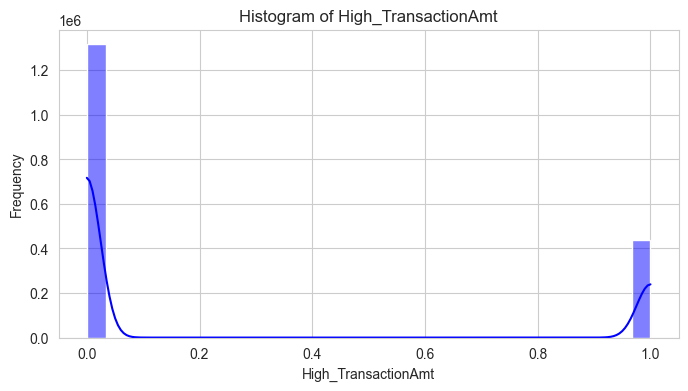

In [15]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style(style="whitegrid")

# Select key numerical features for univariate analysis
numerical_features = comb_df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for numerical features
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(comb_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

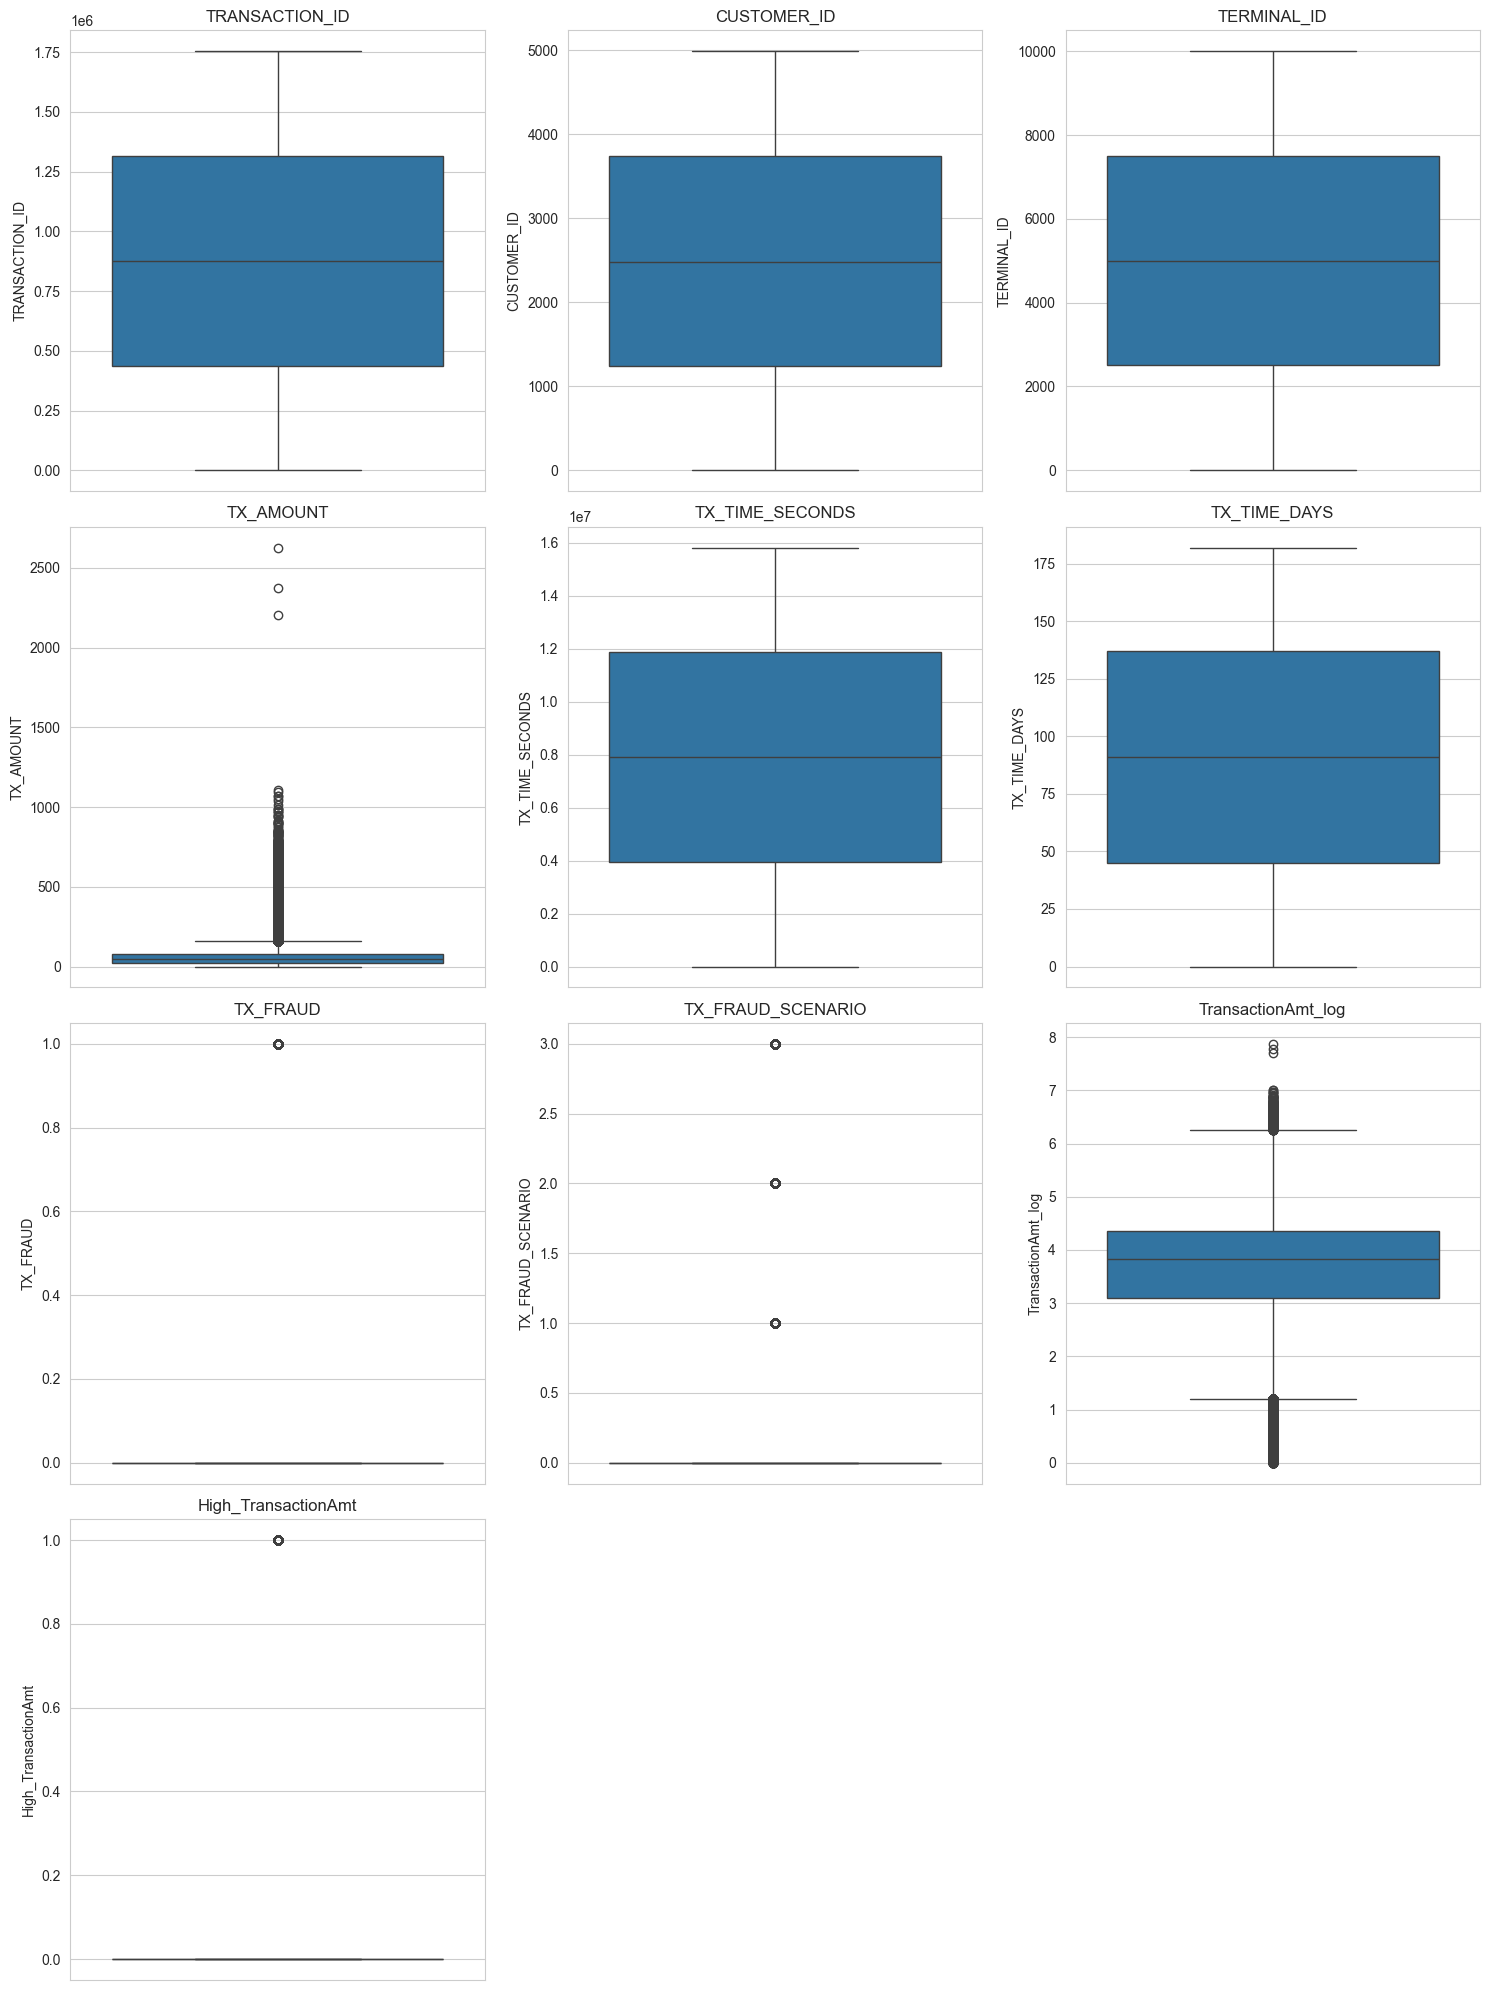

In [16]:
numerical_cols = comb_df.select_dtypes(include=np.number).columns
num_plots = len(numerical_cols)
rows = (num_plots // 3) + (num_plots % 3 > 0)  # Calculate rows dynamically for a 3-column layout

plt.figure(figsize=(15, 5 * rows))  # Adjust figure size based on rows
for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(y=comb_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

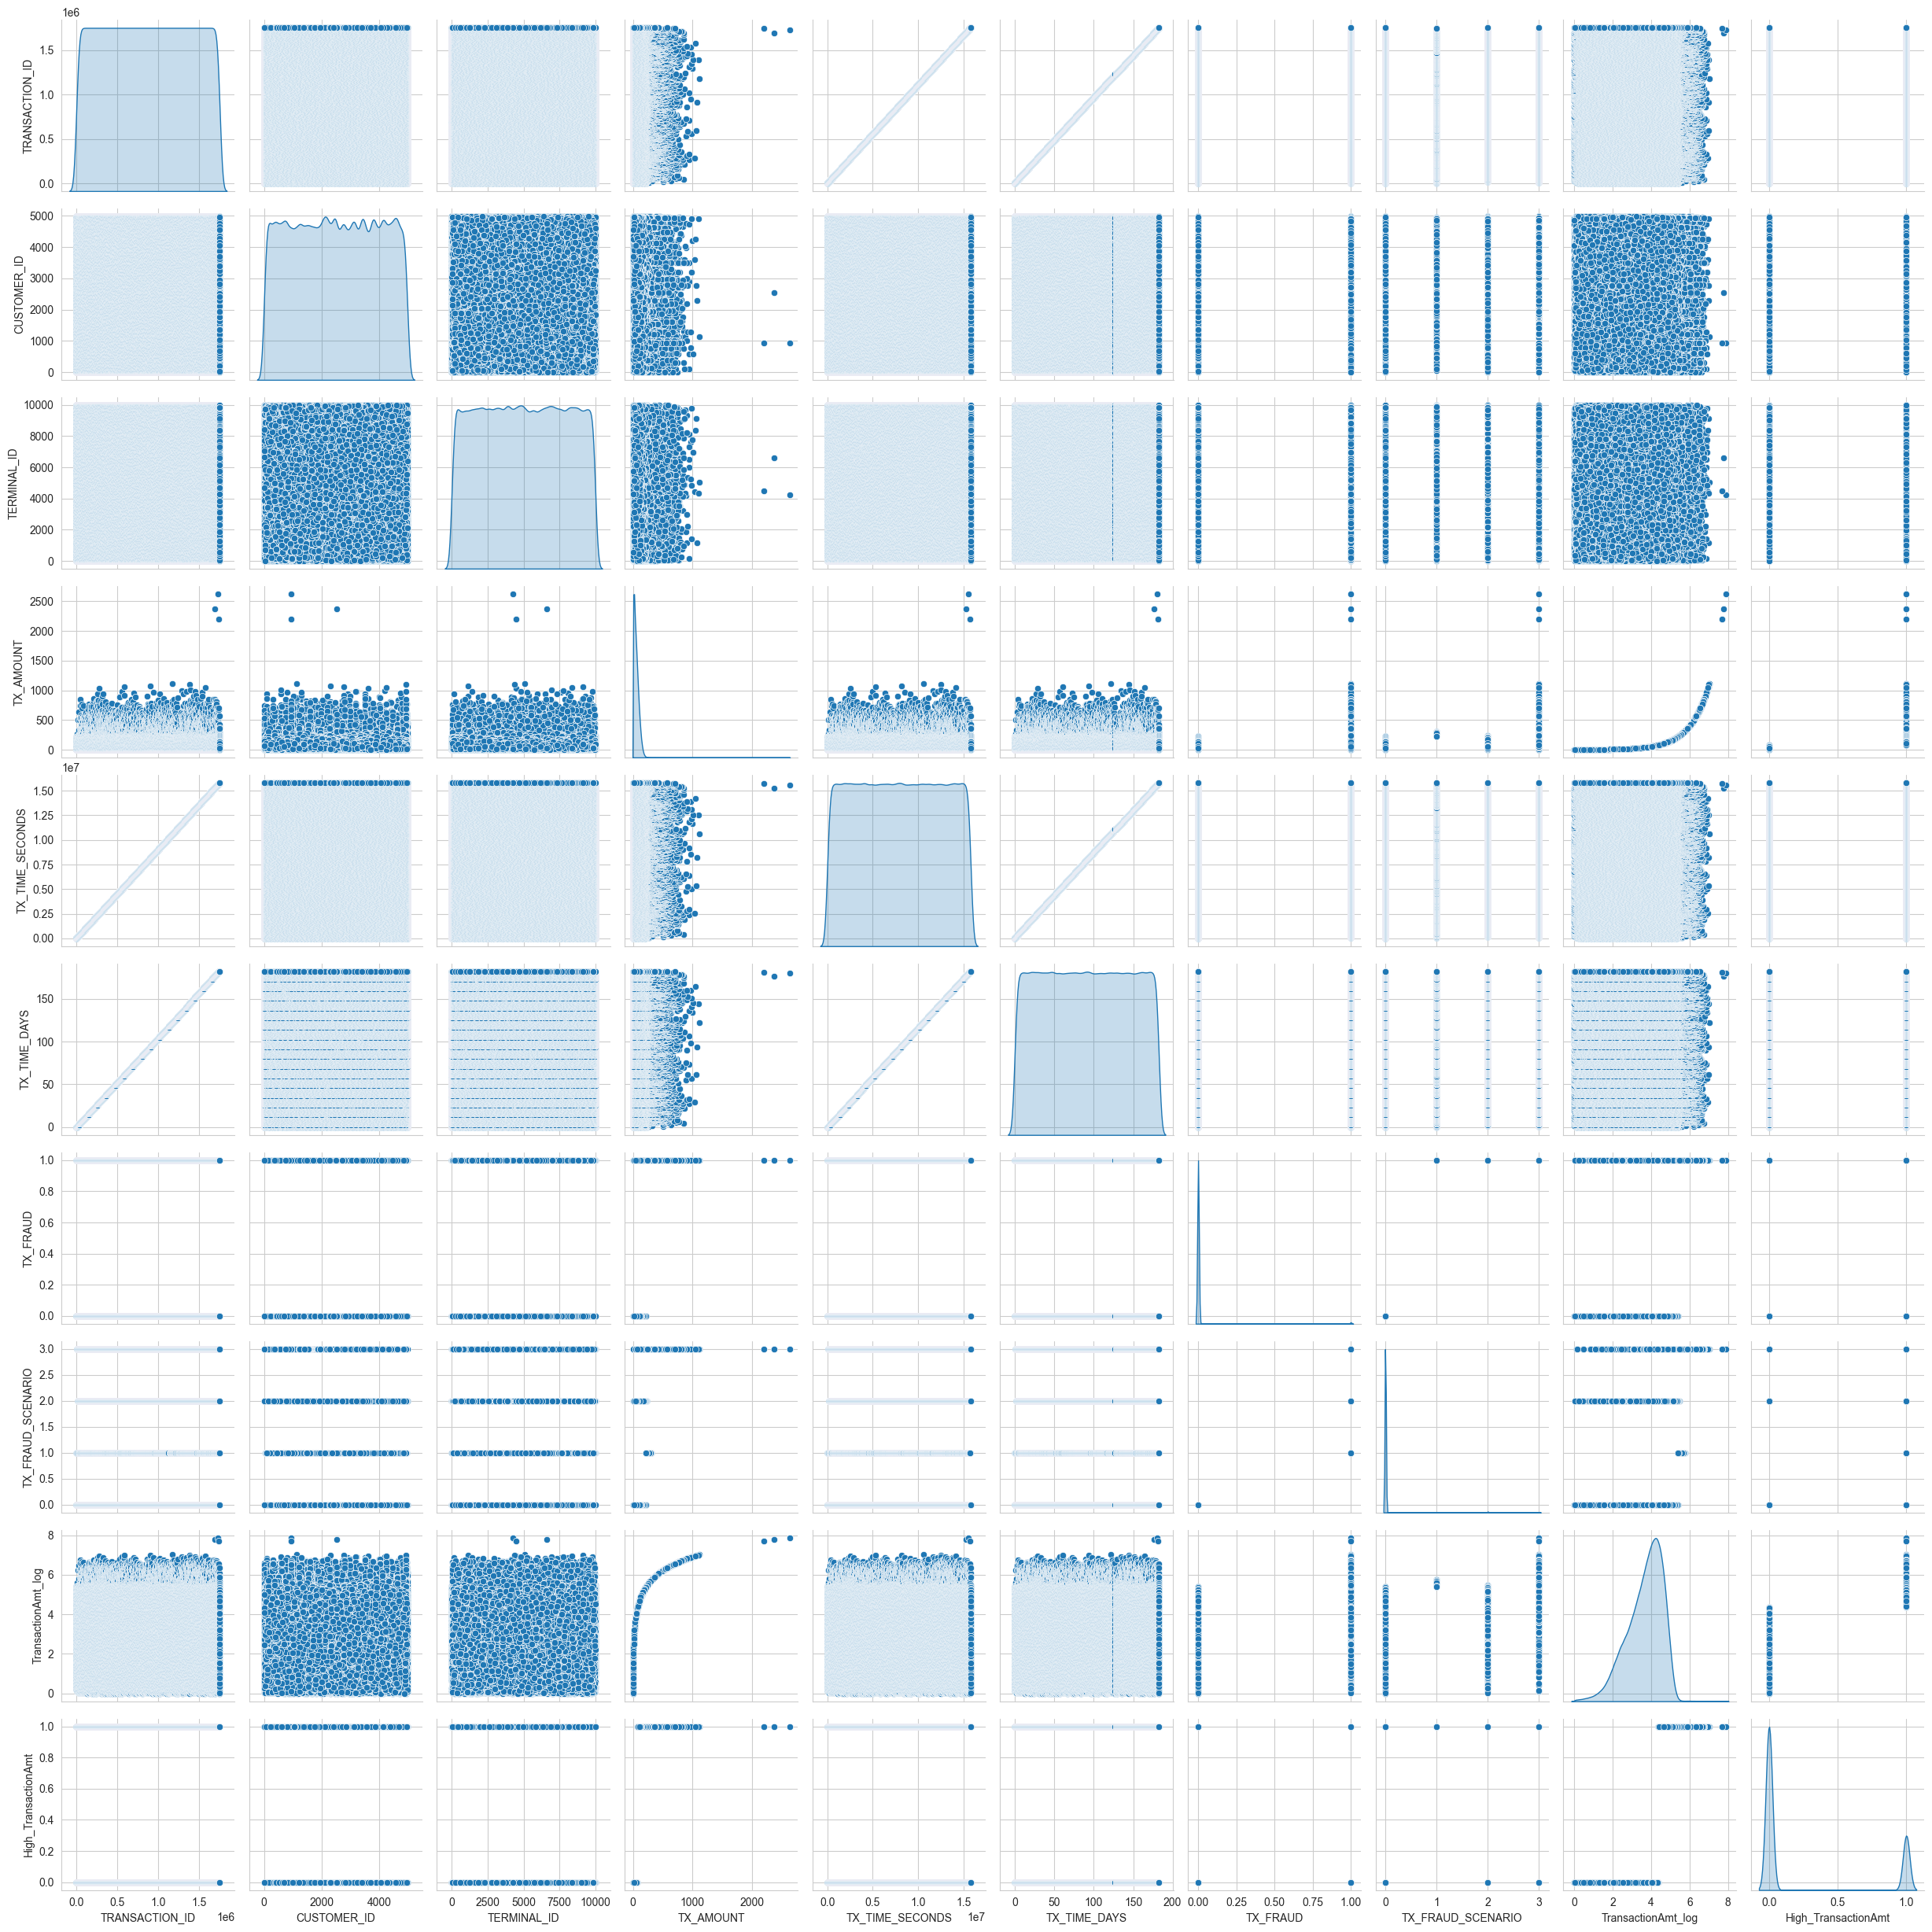

In [17]:
# Alternatively, you can use a scatter plot matrix to visualize outliers across multiple features
sns.pairplot(comb_df.select_dtypes(include=np.number), diag_kind='kde')
plt.show()

# Sumerize these graph :

" The provided code analyzes a dataset of transactions, likely for fraud detection. Here's a summary of the graphs:

1. **Box Plots:**
   - These plots visualize the distribution of numerical features in the dataset.
   - They highlight the presence of outliers, which are data points that lie significantly outside the typical range of the feature's values.
   - Outliers can indicate unusual or potentially fraudulent transactions.

2. **Scatter Plot Matrix:**
   - The scatter plot matrix visualizes the relationship between pairs of numerical features in the dataset.
   - It allows us to identify potential correlations or patterns between features.
   - It also helps in detecting outliers that deviate from the general trend across multiple features, potentially hinting at anomalies or fraudulent activities.

**Overall, the purpose of the graphs is to identify outliers and potential patterns in the transaction data, which can be crucial for fraud detection.** The box plots provide a feature-by-feature visualization of outliers, while the scatter plot matrix allows for an exploration of relationships between multiple features and a comprehensive view of potentially anomalous data points. "

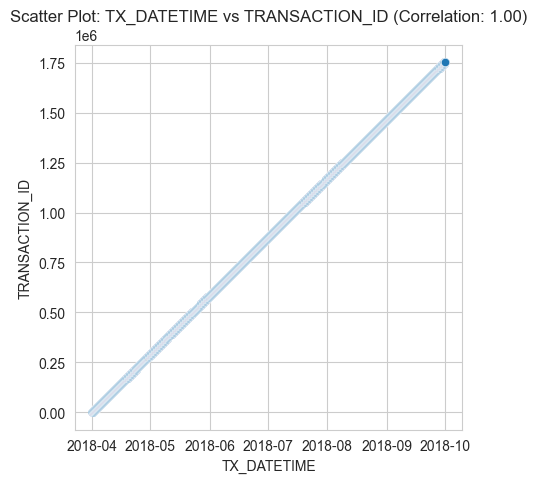

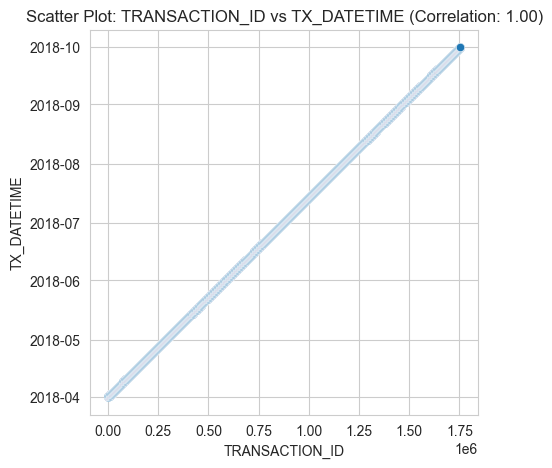

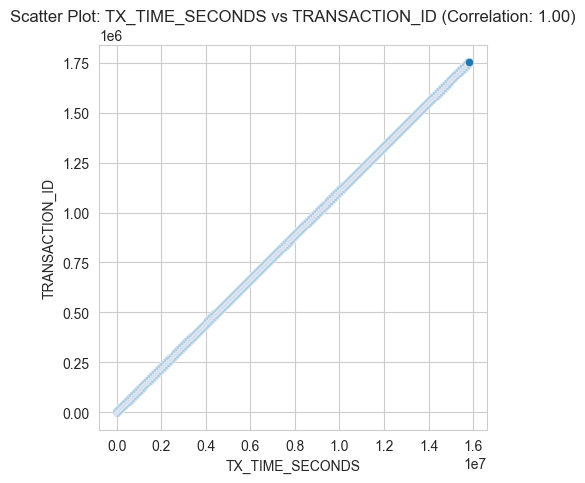

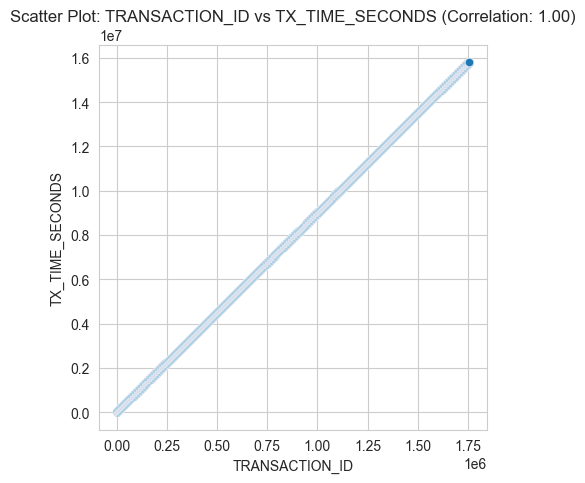

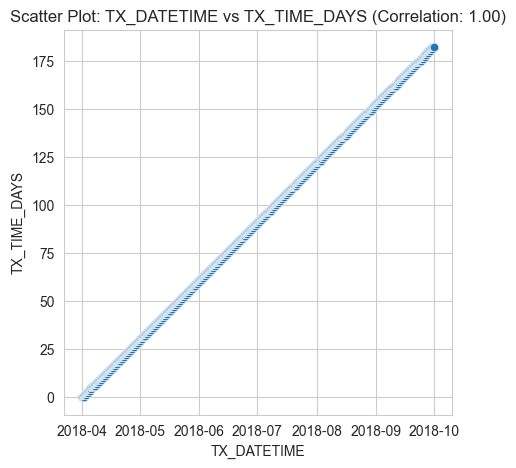

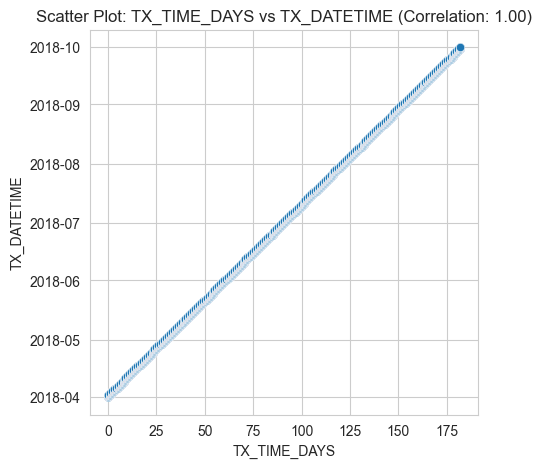

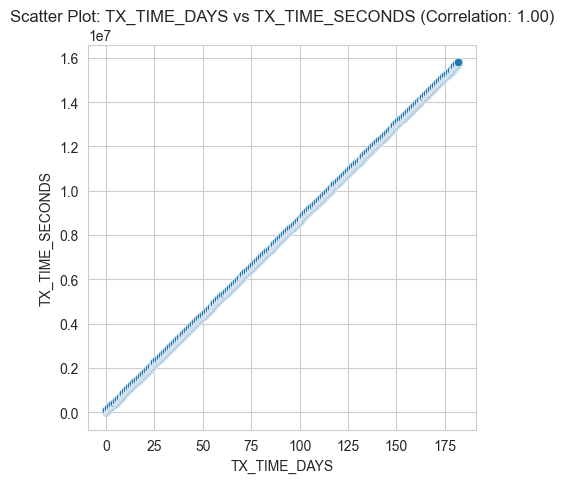

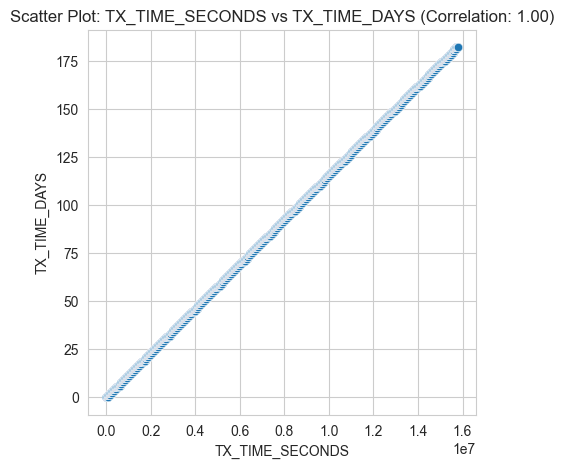

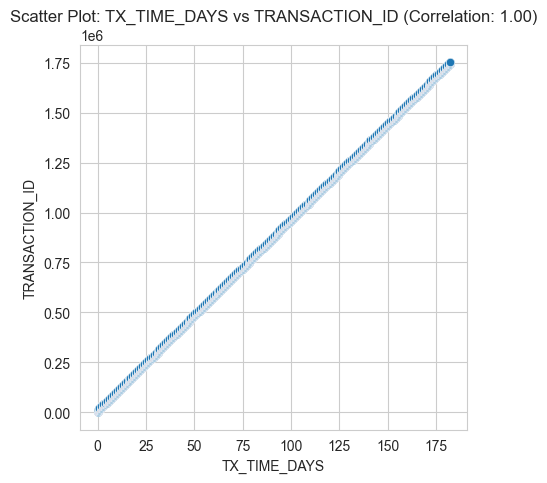

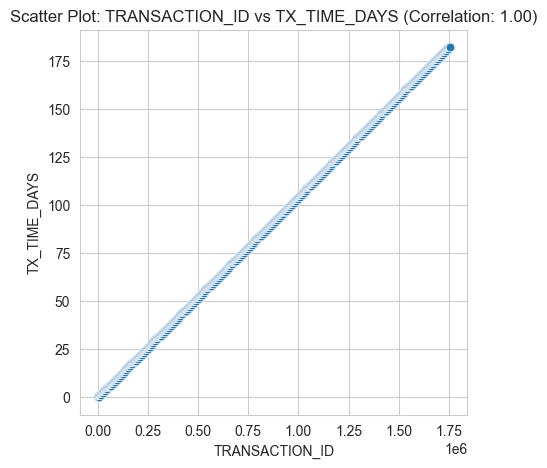

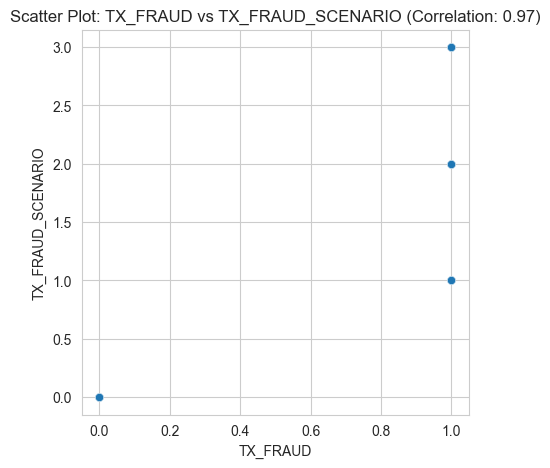

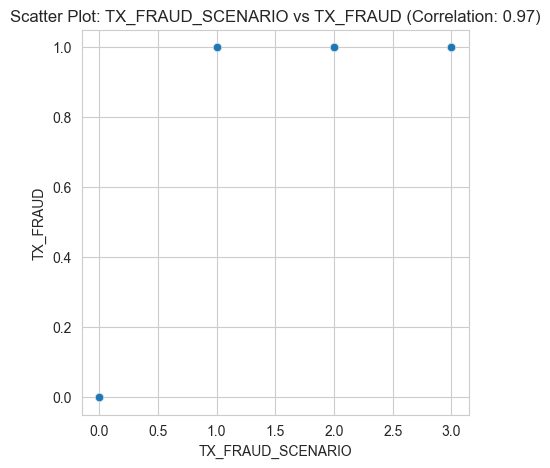

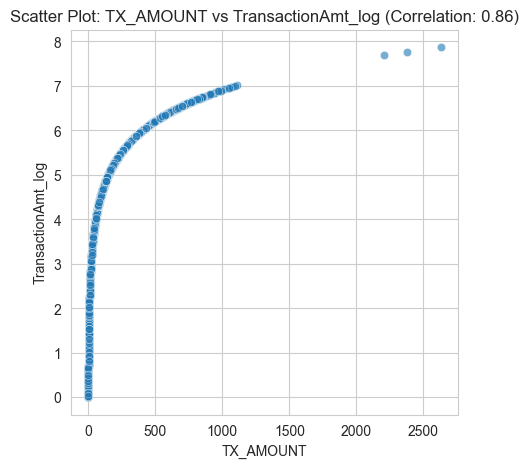

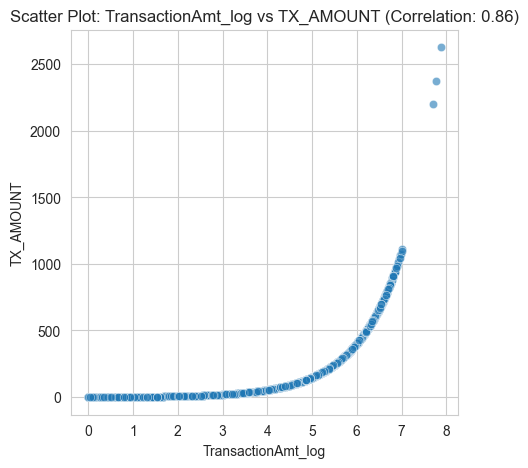

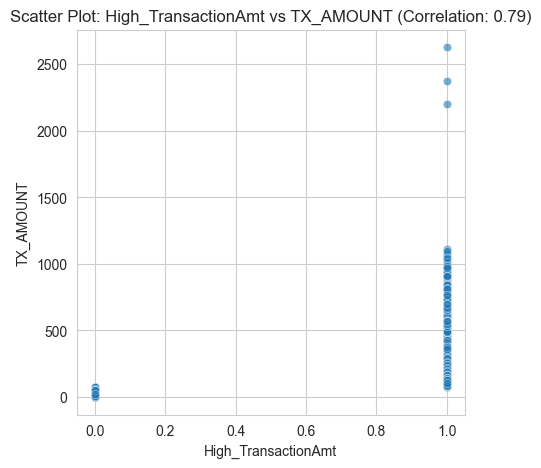

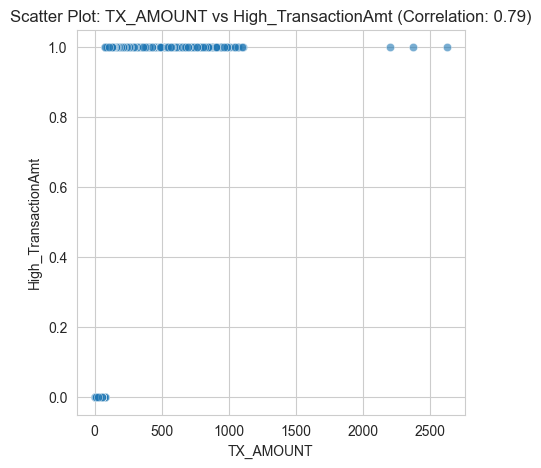

In [18]:
correlation_matrix = comb_df.corr()

# Scatter plots for pairs of highly correlated numerical features (correlation > 0.7)
high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]  # Exclude self-correlation
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.7]  # Filter for high correlation

for (feature1, feature2), corr_value in high_corr_pairs.items():
    plt.figure(figsize=(5, 5))
    sns.scatterplot(data=comb_df, x=feature1, y=feature2, alpha=0.6)
    plt.title(f"Scatter Plot: {feature1} vs {feature2} (Correlation: {corr_value:.2f})")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()


In [19]:
comb_df.corr()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TransactionAmt_log,High_TransactionAmt
TRANSACTION_ID,1.000000,0.999999,0.000923,-0.000543,0.000521,0.999999,0.999985,0.008689,0.008173,-0.000490,0.000184
TX_DATETIME,0.999999,1.000000,0.000923,-0.000543,0.000521,1.000000,0.999992,0.008685,0.008168,-0.000489,0.000185
CUSTOMER_ID,0.000923,0.000923,1.000000,0.000255,-0.000085,0.000923,0.000921,-0.000823,-0.001076,-0.003609,-0.000072
TERMINAL_ID,-0.000543,-0.000543,0.000255,1.000000,0.000486,-0.000543,-0.000543,-0.004297,-0.003732,0.001341,0.000508
TX_AMOUNT,0.000521,0.000521,-0.000085,0.000486,1.000000,0.000521,0.000521,0.168290,0.195008,0.860784,0.785438
TX_TIME_SECONDS,0.999999,1.000000,0.000923,-0.000543,0.000521,1.000000,0.999992,0.008685,0.008168,-0.000489,0.000185
TX_TIME_DAYS,0.999985,0.999992,0.000921,-0.000543,0.000521,0.999992,1.000000,0.008687,0.008169,-0.000488,0.000186
TX_FRAUD,0.008689,0.008685,-0.000823,-0.004297,0.168290,0.008685,0.008687,1.000000,0.969587,0.060905,0.048016
TX_FRAUD_SCENARIO,0.008173,0.008168,-0.001076,-0.003732,0.195008,0.008168,0.008169,0.969587,1.000000,0.068179,0.052903
TransactionAmt_log,-0.000490,-0.000489,-0.003609,0.001341,0.860784,-0.000489,-0.000488,0.060905,0.068179,1.000000,0.643017


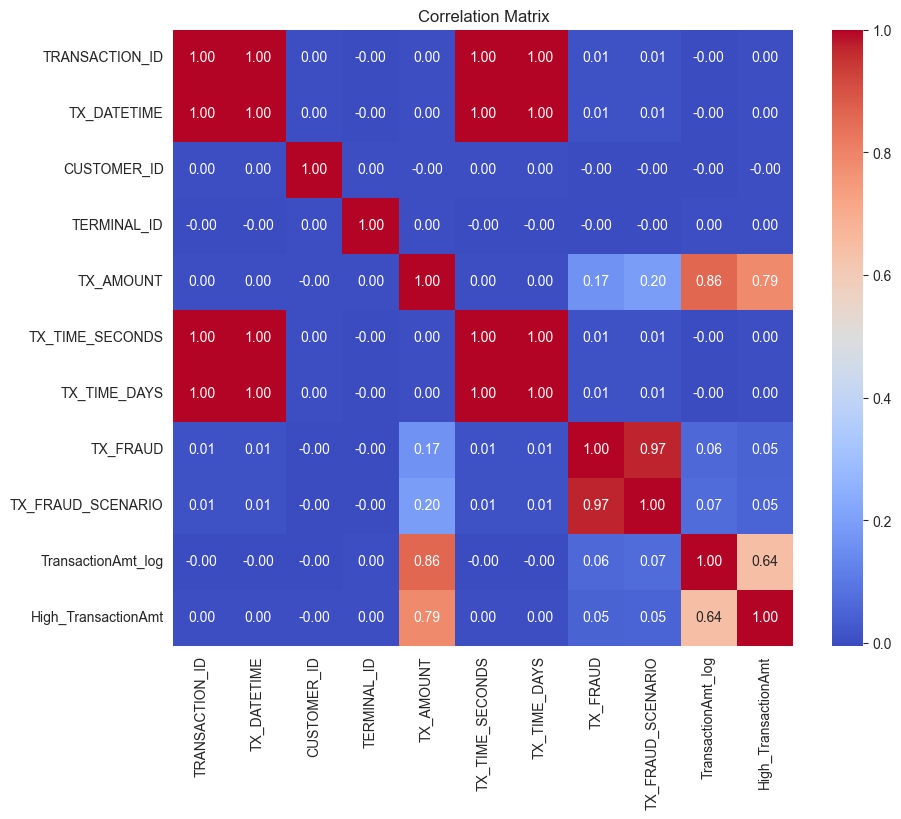

In [20]:
# prompt: heat map

# Assuming 'combined_df' is your DataFrame
correlation_matrix = comb_df.corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [21]:
# prompt: remove all the unnecessary columns for "combined_df " which is not contributing to the dataset

# Assuming 'combined_df' is your DataFrame
columns_to_remove = ['TRANSACTION_ID', 'TX_DATETIME', 'TX_TIME_DAYS', 'TX_TIME_SECONDS', 'TERMINAL_ID', 'CUSTOMER_ID']
ml_df = comb_df.drop(columns=columns_to_remove, errors='ignore')

ml_df.head()

,TX_AMOUNT,TX_FRAUD,TX_FRAUD_SCENARIO,TransactionAmt_log,High_TransactionAmt
0,57.16,0,0,4.063198,0
1,81.51,0,0,4.412919,1
2,146.00,0,0,4.990433,1
3,64.49,0,0,4.181897,0
4,50.99,0,0,3.951051,0


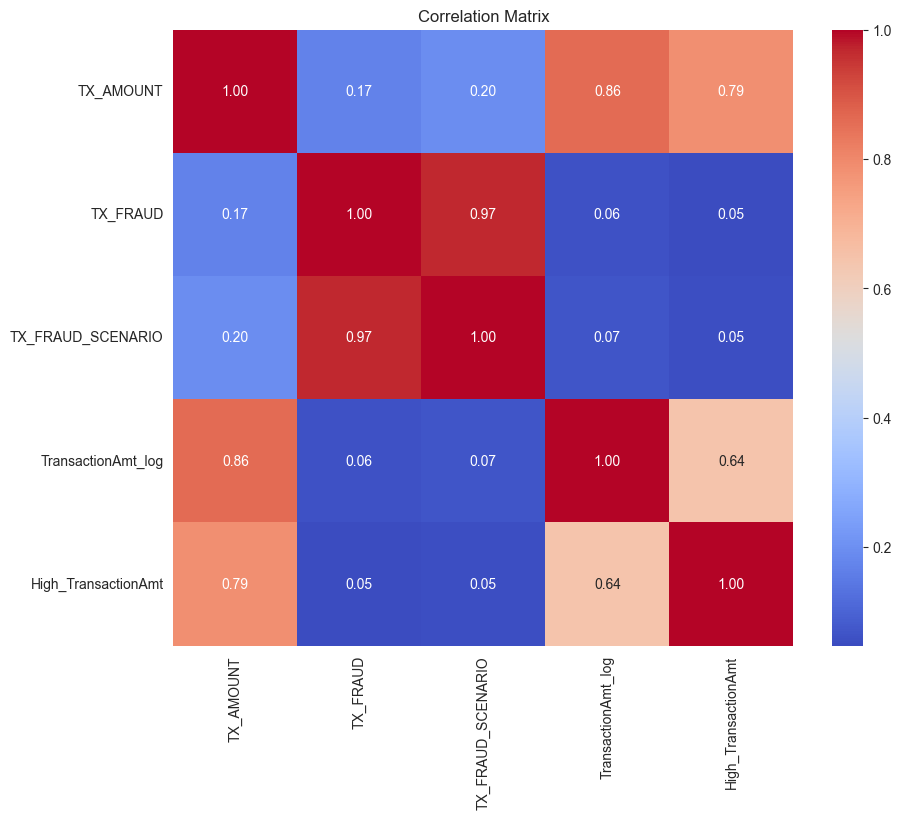

In [22]:
# prompt: heat map

# Assuming 'combined_df' is your DataFrame
correlation_matrix = ml_df.corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [24]:
# Export the final dataset to a CSV file
output_path = r"d:\Projects\fraud_detection\final_dataset.csv"  # Specify the output file path
ml_df.to_csv(output_path, index=False)
print(f"Final dataset exported to {output_path}")

Final dataset exported to d:\Projects\fraud_detection\final_dataset.csv
